
Accuracy Comparison:
Decision Tree Accuracy: 0.6222222222222222
Random Forest accuracy: 0.6666666666666666

Decision Tree Confusion Matrix:
 [[29 17]
 [17 27]]

Random Forest Confusion Matrix:
 [[29 17]
 [13 31]]


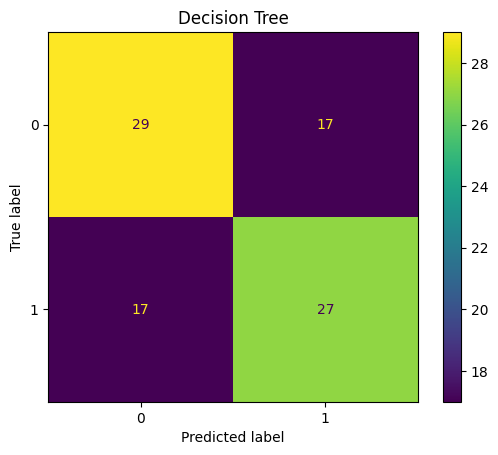

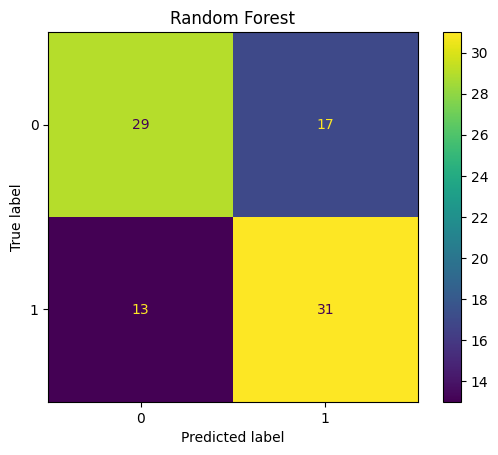


Cross Validation Accuracy:
Decision Tree: 0.5566666666666666
random Forest: 0.6266666666666667


In [ ]:
#===============================
#1.Import Libraries
#===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

#================================
#2.Generate Larger Dataset
#================================

np.random.seed(42)
random.seed(42)

n_samples=300

data={
    'Weather':np.random.choice(['Sunny','Cloudy','Rainy'],n_samples),
    'Soil':np.random.choice(['Dry','Moist','Wet'],n_samples),
    'Temperature':np.random.choice(['Hot','Mild','Cool'],n_samples),
    'Humidity':np.random.choice(['High','Medium','Low'],n_samples),
    'Wind':np.random.choice(['Strong','Weak'],n_samples),
    'Fertilizer':np.random.choice(['Yes','No'],n_samples),
    'CropType':np.random.choice(['Wheat','Rice','Corn'],n_samples),
    'Season':np.random.choice(['Kharif','Rabi','Summer'],n_samples)
}

df=pd.DataFrame(data)

#==========================
#3.Target with NOISE
#==========================
def irrigation_rule(row):
  if row['Soil']=='Dry' and row['Weather']!='Rainy':
    base='Yes'
  elif row['Soil']=='Wet':
    base='No'
  else:
    base=np.random.choice(['Yes','No'])

  #Add noise (flip label with 20% probability)
  if random.random()<0.2:
    return 'No' if base=='Yes' else 'Yes'
  return base

df['Irrigate']=df.apply(irrigation_rule,axis=1)

#===========================
#4.Encode Data
#===========================
le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])


#===========================
#5.Split Data
#===========================
X=df.drop('Irrigate',axis=1)
y=df['Irrigate']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42,stratify=y
)

#=========================
#6.Decision Tree(High Variance)
#=========================
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)

#==========================
#7.Random Forest (Variance Reduction)
#==========================
rf_model=RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

#=============================
#8.Accuracy Comparison
#=============================
dt_acc=accuracy_score(y_test,y_pred_dt)
rf_acc=accuracy_score(y_test,y_pred_rf)

print("\nAccuracy Comparison:")
print("Decision Tree Accuracy:",dt_acc)
print("Random Forest accuracy:",rf_acc)

#============================
#9.Confusion Matrix
#============================
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_rf,labels=[0,1])

print("\nDecision Tree Confusion Matrix:\n",cm_dt)
print("\nRandom Forest Confusion Matrix:\n",cm_rf)

#==============================
#10.Visual Confusion Matrix
#==============================
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title("Decision Tree")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf)
plt.title("Random Forest")
plt.show()

#==========================
#11.Cross Validation
#==========================
dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)

print("\nCross Validation Accuracy:")
print("Decision Tree:",dt_cv.mean())
print("random Forest:",rf_cv.mean())